# Inferência bayesiana de janela e modelo: da observação ao forecast

Este tutorial é para quem conhece regressão linear básica, mas quer entender **de onde vem cada objeto** usado pelo pacote. Não começaremos por fórmulas prontas: construiremos as somas, a matriz de informação, a posterior, a evidência e a distribuição preditiva.

Ao final você conseguirá:

- entender por que todas as hipóteses explicam o mesmo histórico;
- construir a matriz de uma janela candidata observação por observação;
- derivar a média e a incerteza dos coeficientes completando quadrados;
- entender como a evidência equilibra ajuste e complexidade;
- reproduzir numericamente a seleção de janela e modelo;
- conferir o cálculo chamando o pacote.


## Roteiro

1. Localizar o pacote.
2. Gerar e inspecionar a série sintética.
3. Construir uma hipótese de janela + modelo.
4. Partir dos erros individuais e chegar à forma matricial.
5. Introduzir a prior e completar o quadrado.
6. Derivar a evidência integrada.
7. Comparar todas as janelas e modelos.
8. Construir o forecast e seus intervalos.
9. Conferir contra a API do pacote.
10. Alterar a ruptura e o ruído.


## 1. Caminho do pacote

Nesta máquina o pacote está em:

`/Users/robinsongarcia/Documents/Codex/2026-09-24/referenced-chatgpt-conversation-this-is-an/outputs/probabilistic-window-forecast`

Abra este notebook no Jupyter e execute **Run All**. A célula seguinte adiciona `src` ao caminho do Python, portanto não é necessário instalar o projeto. Alternativamente, instale o wheel encontrado em `dist/`.


In [1]:
from pathlib import Path
import sys
import math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, logsumexp
from scipy.stats import t as student_t

PACKAGE_ROOT = Path(
    "/Users/robinsongarcia/Documents/Codex/2026-09-24/"
    "referenced-chatgpt-conversation-this-is-an/outputs/"
    "probabilistic-window-forecast"
).resolve()
if not PACKAGE_ROOT.exists():
    here = Path.cwd().resolve()
    PACKAGE_ROOT = next(
        p for p in (here, *here.parents)
        if (p / "pyproject.toml").exists()
        and (p / "src/probabilistic_window_forecast").exists()
    )
sys.path.insert(0, str(PACKAGE_ROOT / "src"))
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("Pacote localizado em:", PACKAGE_ROOT)


Pacote localizado em: /Users/robinsongarcia/Documents/Codex/2026-09-24/referenced-chatgpt-conversation-this-is-an/outputs/probabilistic-window-forecast


## 2. Série sintética: todos os dados de entrada

Criamos 42 meses e **três regimes**, separados por dois change points. O primeiro, no índice 12, é uma mudança histórica. O segundo, no índice 28, inicia o regime corrente que queremos projetar. Cada regime tem nível e inclinação diferentes. O ruído é fixo para que a execução seja reproduzível. O pacote recebe pares `(valor, t)`.


In [2]:
n = 42
change_points = (12, 28)
true_break = change_points[-1]  # início do regime terminal que será projetado
noise_pattern = np.array([0.30, -0.40, 0.20, -0.10, 0.50, -0.20])
dates, values, signal = [], [], []
for i in range(n):
    year, month = 2023 + i // 12, i % 12 + 1
    dates.append(f"{year:04d}-{month:02d}")
    if i < change_points[0]:
        level = 100 + 0.20 * i
    elif i < change_points[1]:
        level = 106 + 0.55 * (i - change_points[0])
    else:
        level = 121 + 1.80 * (i - change_points[1])
    signal.append(level)
    values.append(level + noise_pattern[i % len(noise_pattern)])
y = np.asarray(values, dtype=float)
series = list(zip(y, dates))

print(" i | mês     | sinal sem ruído | ruído | valor observado")
print("---+---------+----------------+-------+----------------")
for i, (date, clean, observed) in enumerate(zip(dates, signal, y)):
    if i == change_points[0]:
        marker = "  <-- change point histórico"
    elif i == change_points[1]:
        marker = "  <-- change point atual / início do regime projetado"
    else:
        marker = ""
    print(f"{i:2d} | {date} | {clean:14.2f} | {observed-clean:5.2f} | {observed:14.2f}{marker}")


 i | mês     | sinal sem ruído | ruído | valor observado
---+---------+----------------+-------+----------------
 0 | 2023-01 |         100.00 |  0.30 |         100.30
 1 | 2023-02 |         100.20 | -0.40 |          99.80
 2 | 2023-03 |         100.40 |  0.20 |         100.60
 3 | 2023-04 |         100.60 | -0.10 |         100.50
 4 | 2023-05 |         100.80 |  0.50 |         101.30
 5 | 2023-06 |         101.00 | -0.20 |         100.80
 6 | 2023-07 |         101.20 |  0.30 |         101.50
 7 | 2023-08 |         101.40 | -0.40 |         101.00
 8 | 2023-09 |         101.60 |  0.20 |         101.80
 9 | 2023-10 |         101.80 | -0.10 |         101.70
10 | 2023-11 |         102.00 |  0.50 |         102.50
11 | 2023-12 |         102.20 | -0.20 |         102.00
12 | 2024-01 |         106.00 |  0.30 |         106.30  <-- change point histórico
13 | 2024-02 |         106.55 | -0.40 |         106.15
14 | 2024-03 |         107.10 |  0.20 |         107.30
15 | 2024-04 |         107.65 | -0

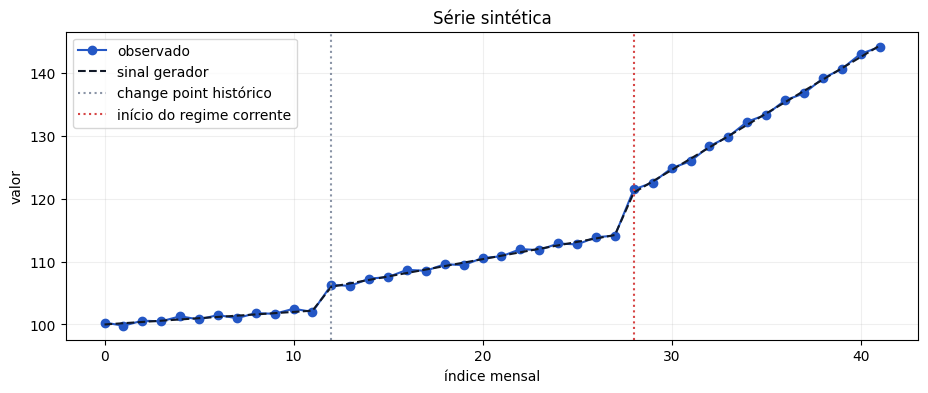

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(n), y, "o-", label="observado", color="#2457C5")
ax.plot(range(n), signal, "--", label="sinal gerador", color="#111827")
ax.axvline(change_points[0], color="#8A94A6", linestyle=":", label="change point histórico")
ax.axvline(change_points[1], color="#D64545", linestyle=":", label="início do regime corrente")
ax.set(xlabel="índice mensal", ylabel="valor", title="Série sintética")
ax.legend(); ax.grid(alpha=0.2); plt.show()


## 3. O que está sendo comparado?

Uma hipótese responde simultaneamente: **quando começou o regime corrente?** e **qual forma o descreve?** A janela pode ser uma data candidata ou “sem mudança”; o modelo pode ser constante, linear ou logarítmico.

Todas as hipóteses explicam os mesmos 42 pontos. Se propomos o início terminal no índice 28, os pontos 0–27 são tratados como histórico anterior e os pontos 28–41 como regime corrente. Assim uma janela curta não ganha simplesmente por descartar observações difíceis.

**Escopo do MVP:** cada hipótese do pacote contém no máximo um change point terminal. Portanto ele não devolverá os dois change points como uma segmentação completa. O primeiro change point permanece dentro do trecho histórico, que é resumido por uma reta de apoio. O objetivo é verificar se, apesar da mudança antiga, a posterior identifica o segundo change point como início do estado atual. Recuperar todos os regimes exigiria estender o modelo para múltiplos segmentos.

Começaremos com a hipótese `início terminal=28, modelo=linear`.


## 4. A matriz nasce da equação de cada ponto

Antes da ruptura, o ponto usa `pre_intercept + pre_slope × idade_pre`. Depois, usa `post_intercept + post_slope × idade_post`. Logo existem quatro coeficientes. Cada linha de `X` contém os multiplicadores desses coeficientes. Zeros desligam o regime que não pertence àquela observação.

Antes de montar `X`, retiramos a mediana da própria série e dividimos pelo MAD (`1,4826 × mediana(|y-mediana(y)|)`). A transformação é comum a todas as hipóteses. Ela faz `z=0` representar o nível típico observado, sem precisar estimar uma população de séries.


In [4]:
center = float(np.median(y))
mad_scale = 1.4826 * float(np.median(np.abs(y-center)))
scale = mad_scale if mad_scale > 1e-8 else max(float(np.std(y-center)), abs(center), 1.0)
z = (y-center) / scale
candidate_start = true_break
X = np.zeros((n, 4))
for i in range(n):
    X[i] = [1, i, 0, 0] if i < candidate_start else [0, 0, 1, i-candidate_start]

print(f"centro (mediana) = {center:.6f}")
print(f"escala robusta   = {scale:.6f}")
print("primeiros valores normalizados:", z[:6])
print("colunas: [pre_intercept, pre_slope, post_intercept, post_slope]")
for i in range(15, 22):
    print(f"i={i:2d}, z={z[i]:.5f}, X[i]={X[i]}")


centro (mediana) = 110.725000
escala robusta   = 13.825245
primeiros valores normalizados: [-0.7541 -0.7902 -0.7324 -0.7396 -0.6817 -0.7179]
colunas: [pre_intercept, pre_slope, post_intercept, post_slope]
i=15, z=-0.22965, X[i]=[ 1. 15.  0.  0.]
i=16, z=-0.14647, X[i]=[ 1. 16.  0.  0.]
i=17, z=-0.15732, X[i]=[ 1. 17.  0.  0.]
i=18, z=-0.08137, X[i]=[ 1. 18.  0.  0.]
i=19, z=-0.09222, X[i]=[ 1. 19.  0.  0.]
i=20, z=-0.00904, X[i]=[ 1. 20.  0.  0.]
i=21, z=0.00904, X[i]=[ 1. 21.  0.  0.]


## 5. Da soma dos erros à forma matricial

Para coeficientes `beta`, a previsão do ponto `i` é `X[i] @ beta` e o erro é `z[i] - X[i] @ beta`. Expandir o quadrado do erro gera: um termo `z[i]²`, um termo linear em `beta` e um termo quadrático contendo o produto externo `X[i]'X[i]`.

Ao somar os pontos aparecem `sum X[i]'X[i]` e `sum X[i]z[i]`. As abreviações `X.T @ X` e `X.T @ z` são literalmente essas somas, como mostramos agora.


In [5]:
sum_outer = np.zeros((4, 4))
sum_xz = np.zeros(4)
sum_z2 = 0.0
for xi, zi in zip(X, z):
    sum_outer += np.outer(xi, xi)
    sum_xz += xi * zi
    sum_z2 += zi**2
print("soma dos produtos externos:")
print(sum_outer)
print()
print("X.T @ X:")
print(X.T @ X)
print("iguais?", np.allclose(sum_outer, X.T @ X))
print()
print("soma X[i]z[i]:", sum_xz)
print("X.T @ z:       ", X.T @ z)
print("iguais?", np.allclose(sum_xz, X.T @ z))
print()
print("soma z[i]²:", sum_z2, "; z.T @ z:", float(z @ z))


soma dos produtos externos:
[[  28.  378.    0.    0.]
 [ 378. 6930.    0.    0.]
 [   0.    0.   14.   91.]
 [   0.    0.   91.  819.]]

X.T @ X:
[[  28.  378.    0.    0.]
 [ 378. 6930.    0.    0.]
 [   0.    0.   14.   91.]
 [   0.    0.   91.  819.]]
iguais? True

soma X[i]z[i]: [ -8.9619 -42.9323  22.3179 174.5665]
X.T @ z:        [ -8.9619 -42.9323  22.3179 174.5665]
iguais? True

soma z[i]²: 45.764990428752725 ; z.T @ z: 45.76499042875271


In [6]:
beta_demo = np.array([0.90, 0.002, 1.00, 0.015])
rss_residuos = float((z - X @ beta_demo) @ (z - X @ beta_demo))
rss_expandido = float(z@z - 2*beta_demo@(X.T@z) + beta_demo@(X.T@X)@beta_demo)
print("beta de demonstração:", beta_demo)
print("RSS pelos resíduos:         ", rss_residuos)
print("RSS expandindo os quadrados:", rss_expandido)
print("diferença:", abs(rss_residuos-rss_expandido))


beta de demonstração: [0.9   0.002 1.    0.015]
RSS pelos resíduos:          53.17814163582184
RSS expandindo os quadrados: 53.178141635821824
diferença: 1.4210854715202004e-14


## 6. Derivando cada linha: de duas penalidades a uma posterior

O bloco de código abaixo combina **duas fontes de informação** sobre o mesmo vetor de quatro coeficientes:

`beta = [pre_intercept, pre_slope, post_intercept, post_slope]`.

A primeira fonte são os dados. A segunda é a prior. Antes de olhar as matrizes, vale acompanhar o caminho algébrico de cada uma.

### 6.1 O que os dados entregam

Assumimos `z = X @ beta + erro`. Para um `beta` candidato, a falta de ajuste é `z - X @ beta`. Com erros normais de variância `sigma²`, a parte relevante da log-verossimilhança negativa é a soma dos erros quadráticos dividida por `2 sigma²`.

Ao expandir `(z - X beta)'(z - X beta)`, obtemos três partes:

- `z' z`: constante; não muda quando beta muda;
- `-2 beta' X' z`: termo linear em beta; ele aponta para onde os dados querem deslocar o centro;
- `beta' X' X beta`: termo quadrático; ele mede quanto a penalidade cresce ao afastar beta do centro.

Por isso `X.T @ X` será chamado de **precisão dos dados** e `X.T @ z` de **vetor de informação dos dados**. Esses nomes não são definições arbitrárias: são os coeficientes quadrático e linear que apareceram na expansão.

### 6.2 O que a prior entrega

A prior diz `beta | sigma² ~ Normal(b0, sigma² V0)`. Aqui:

- `b0` é o vetor de valores centrais; usamos zero porque a série já foi centralizada pela mediana;
- `V0` controla a largura e as correlações da prior, em unidades relativas ao ruído;
- `sigma² V0` é a covariância condicional efetiva dos coeficientes.

A densidade normal prior acrescenta a penalidade `(beta-b0)' inv(V0) (beta-b0)`. Em uma dimensão, isso seria simplesmente `(beta-b0)² / variancia`: dividir pela variância é o que transforma dispersão em precisão. Em várias dimensões, a operação equivalente é a inversa da matriz. Por isso aparece `prior_precision = inv(V0)`.

Expandir a penalidade da prior também gera um termo quadrático e um linear:

- quadrático: `beta' inv(V0) beta`;
- linear: `-2 beta' inv(V0) b0`;
- constante: `b0' inv(V0) b0`.

Logo a prior entrega `inv(V0)` como precisão e `inv(V0) @ b0` como vetor de informação. Ainda falta escolher `V0`. Em vez da diagonal arbitrária `[100, 1, ...]`, usamos a geometria da própria hipótese: `V0 = g inv(X.T @ X)`. Com `g=n`, a precisão da prior é `X.T @ X / n`, aproximadamente a informação de uma observação média.

### 6.3 Somando prior e dados

Multiplicar prior e verossimilhança significa somar seus logaritmos. Os termos quadráticos se somam e os termos lineares se somam. Chamando a soma quadrática de `posterior_precision` e a soma linear de `information`, toda a parte que depende de beta fica com a forma `beta' posterior_precision beta - 2 beta' information`.

O gradiente dessa expressão é `2 posterior_precision beta - 2 information`. No ponto central da posterior o gradiente é zero. Portanto o centro `bn` precisa resolver o sistema `posterior_precision @ bn = information`. `np.linalg.solve` faz exatamente isso.

Finalmente, uma Normal escrita ao redor de `bn` tem o termo quadrático `(beta-bn)' inv(Vn) (beta-bn)`. Como a matriz que acabamos de obter é a precisão, ela é `inv(Vn)`; consequentemente `Vn = inv(posterior_precision)`.

O fator comum `1/sigma²` não aparece nessas oito linhas porque ele multiplica tanto a penalidade dos dados quanto a da prior e pode ser colocado em evidência. `Vn` é a dispersão-base; a covariância condicional completa é `sigma² Vn`.


In [7]:
parameter_names = ["pre_intercept", "pre_slope", "post_intercept", "post_slope"]

# CENTRO DA PRIOR: zero tem sentido porque z foi centralizado.
b0 = np.zeros(4)
# CONTRIBUIÇÃO DOS DADOS: coeficientes quadrático e linear.
data_precision = X.T @ X
data_information = X.T @ z

# G-PRIOR DE INFORMAÇÃO UNITÁRIA: g=n.
g = float(n)
V0 = g * np.linalg.inv(data_precision)
prior_precision = data_precision / g
prior_information = prior_precision @ b0

# MULTIPLICAR PRIOR E VEROSSIMILHANÇA = somar essas contribuições.
posterior_precision = prior_precision + data_precision
information = prior_information + data_information

# Zerar o gradiente produz: posterior_precision @ bn = information.
bn = np.linalg.solve(posterior_precision, information)

# A covariância-base é a inversa da precisão.
Vn = np.linalg.inv(posterior_precision)

print("ORDEM DOS COEFICIENTES")
print(parameter_names)
print()
print("b0: centro escolhido para a prior")
print(b0)
print()
print(f"g = n = {g:.0f}; a prior equivale a cerca de uma observação")
print("V0 = g × inv(X.T @ X):")
print(V0)
print()
print("precisão da prior:")
print(prior_precision)
print("informação da prior = precisão da prior @ b0:", prior_information)
print()
print("precisão dos dados:")
print(data_precision)
print("informação dos dados = X.T @ z:", data_information)
print()
print("precisão posterior = soma:")
print(posterior_precision)
print()
print("informação posterior = prior + dados:", information)
print("centro posterior normalizado:", bn)
original_parameters = scale*bn
original_parameters[[0,2]] += center
print("centro na escala original:    ", original_parameters)
print("gradiente/2 em bn (deve ser zero):", posterior_precision@bn-information)
print()
print("Vn = inversa da precisão:")
print(Vn)


ORDEM DOS COEFICIENTES
['pre_intercept', 'pre_slope', 'post_intercept', 'post_slope']

b0: centro escolhido para a prior
[0. 0. 0. 0.]

g = n = 42; a prior equivale a cerca de uma observação
V0 = g × inv(X.T @ X):
[[ 5.6897 -0.3103  0.      0.    ]
 [-0.3103  0.023  -0.     -0.    ]
 [ 0.      0.     10.8    -1.2   ]
 [-0.     -0.     -1.2     0.1846]]

precisão da prior:
[[  0.6667   9.       0.       0.    ]
 [  9.     165.       0.       0.    ]
 [  0.       0.       0.3333   2.1667]
 [  0.       0.       2.1667  19.5   ]]
informação da prior = precisão da prior @ b0: [0. 0. 0. 0.]

precisão dos dados:
[[  28.  378.    0.    0.]
 [ 378. 6930.    0.    0.]
 [   0.    0.   14.   91.]
 [   0.    0.   91.  819.]]
informação dos dados = X.T @ z: [ -8.9619 -42.9323  22.3179 174.5665]

precisão posterior = soma:
[[  28.6667  387.        0.        0.    ]
 [ 387.     7095.        0.        0.    ]
 [   0.        0.       14.3333   93.1667]
 [   0.        0.       93.1667  838.5   ]]

inform

### 6.4 De onde vieram `b0` e `V0` neste exemplo?

`b0` e `V0` cumprem papéis diferentes. `b0=0` vem da decisão de centralizar a série pela mediana: zero passa a significar o nível típico, e slope zero significa ausência de direção anterior. Não precisamos inventar um nível populacional.

A escala de `V0` vem da própria matriz de desenho, mas por uma regra fixada antes da comparação:

`V0 = g × inv(X.T @ X)`.

A derivação é direta. `X.T @ X` é a precisão entregue pela amostra inteira; sua inversa tem a geometria de uma covariância. Multiplicar por `g` alarga essa covariância. Equivalentemente, `inv(V0)=X.T @ X/g`.

Escolhemos `g=n`. A precisão anterior é então a precisão da amostra dividida por `n`: aproximadamente a informação de uma observação média. É a chamada prior de informação unitária.

Note que `V0` não é diagonal. Intercepto e slope podem ficar correlacionados porque a própria base os torna correlacionados. E cada modelo recebe uma `V0` compatível com sua base: idade linear e `log(1+idade)` não são tratados como se tivessem a mesma unidade.

A célula seguinte verifica numericamente a interpretação de informação unitária e mostra o fator de contração resultante.


In [8]:
ols = np.linalg.solve(data_precision, data_information)
shrinkage = g/(g+1)
print("inv(V0) é igual a (X.T @ X)/g?", np.allclose(prior_precision, data_precision/g))
print(f"g={g:.0f}; fator de contração g/(g+1)={shrinkage:.8f}")
print("OLS:                  ", ols)
print("g/(g+1) × OLS:      ", shrinkage*ols)
print("centro posterior bn:", bn)
print("coincidem?", np.allclose(shrinkage*ols, bn))
print()
print(f"número de condição de X: {np.linalg.cond(X):.3f}")
print("V0 contém correlações induzidas pela geometria de X:")
print(V0)


inv(V0) é igual a (X.T @ X)/g? True
g=42; fator de contração g/(g+1)=0.97674419
OLS:                   [-0.8968  0.0427  0.7513  0.1297]
g/(g+1) × OLS:       [-0.876   0.0417  0.7338  0.1267]
centro posterior bn: [-0.876   0.0417  0.7338  0.1267]
coincidem? True

número de condição de X: 42.538
V0 contém correlações induzidas pela geometria de X:
[[ 5.6897 -0.3103  0.      0.    ]
 [-0.3103  0.023  -0.     -0.    ]
 [ 0.      0.     10.8    -1.2   ]
 [-0.     -0.     -1.2     0.1846]]


#### Leitura crítica

A g-prior resolve o problema de unidade entre bases, mas não torna a prior verdadeira. `g=n` continua sendo uma convenção. Por isso o pacote repete a inferência com `g=n/2`, `g=n` e `g=2n`. Se a janela ou o modelo vencedor mudar, `prior_sensitive=True` e a série é encaminhada para revisão. Não escolhemos o melhor `g` com estes mesmos dados; testamos se a conclusão sobrevive a uma vizinhança razoável.


### Completar o quadrado

Depois de combinar prior e dados, a parte que depende de beta é `beta' posterior_precision beta - 2 beta' information`. Queremos reescrevê-la como uma distância ao novo centro.

Expanda `(beta-bn)' posterior_precision (beta-bn)`. O resultado contém `beta' posterior_precision beta`, o termo linear `-2 beta' posterior_precision bn` e uma constante. Para o termo linear coincidir com `-2 beta' information`, necessariamente `posterior_precision @ bn = information`. Essa é outra forma de chegar ao mesmo sistema resolvido por `np.linalg.solve`.

O que resta depois de retirar a distância ao centro não depende mais de beta. Essa `sobra` combina `z'z`, a constante da prior e a correção pelo novo centro. Ela será usada na atualização da variância residual.

A célula seguinte escolhe um beta qualquer e verifica numericamente que a penalidade original e a forma completada são a mesma quantidade.


In [9]:
beta_test = np.array([0.91, 0.001, 1.01, 0.014])
lado_original = float((z-X@beta_test)@(z-X@beta_test) + (beta_test-b0)@prior_precision@(beta_test-b0))
sobra = float(z@z + b0@prior_precision@b0 - bn@posterior_precision@bn)
lado_reorganizado = float((beta_test-bn)@posterior_precision@(beta_test-bn) + sobra)
print("penalidade original:                    ", lado_original)
print("distância ao centro posterior + sobra:", lado_reorganizado)
print("sobra que não depende de beta:         ", sobra)
print("diferença:", abs(lado_original-lado_reorganizado))


penalidade original:                     54.06232931950991
distância ao centro posterior + sobra: 54.06232931950988
sobra que não depende de beta:          1.2196007496268066
diferença: 2.842170943040401e-14


## 7. A variância residual também é desconhecida

A prior Inverse-Gamma da variância usa `a0` como quantidade prévia de informação e `d0` como escala. A verossimilhança de `n` erros normais acrescenta `n/2` à forma porque sua densidade contém uma potência de `sigma²`. A sobra do quadrado acrescenta metade de seu valor à escala porque aparece dividida por `2 sigma²` no expoente.


In [10]:
a0, d0 = 2.0, 0.001
an = a0 + n/2
dn = d0 + 0.5*sobra
mean_sigma2_z = dn/(an-1)
mean_sigma2_y = scale**2 * mean_sigma2_z
print(f"a0={a0}; dados acrescentam n/2={n/2}; an={an}")
print(f"d0={d0:.6f}; erro acrescenta sobra/2={sobra/2:.6f}; dn={dn:.6f}")
print(f"E[sigma²|dados], normalizada = {mean_sigma2_z:.8f}")
print(f"E[sigma²|dados], original    = {mean_sigma2_y:.6f}")
print(f"desvio residual posterior   = {math.sqrt(mean_sigma2_y):.4f}")


a0=2.0; dados acrescentam n/2=21.0; an=23.0
d0=0.001000; erro acrescenta sobra/2=0.609800; dn=0.610800
E[sigma²|dados], normalizada = 0.02776365
E[sigma²|dados], original    = 5.306673
desvio residual posterior   = 2.3036


## 8. De onde vem a evidência?

Para comparar hipóteses, integramos `verossimilhança × prior` sobre todos os `beta` e `sigma²`. Primeiro, integrar a parte quadrática em `beta` gera um fator de volume: o quociente entre os determinantes de `V_n` e `V0`. Ele mede quanto o espaço plausível foi comprimido pelos dados; modelos flexíveis pagam se apenas uma região pequena de seus parâmetros funciona.

Depois sobra uma integral Inverse-Gamma em `sigma²`. Sua constante de normalização produz potências de `d0` e `dn` e funções Gamma. A célula exibe cada parcela do log da evidência.


In [11]:
_, logdetV0 = np.linalg.slogdet(V0)
_, logdetVn = np.linalg.slogdet(Vn)
terms = {
    "constante Normal": -0.5*n*math.log(2*math.pi),
    "compressão do volume": 0.5*(logdetVn-logdetV0),
    "escala anterior de ruído": a0*math.log(d0),
    "escala posterior de ruído": -an*math.log(dn),
    "normalizações Gamma": gammaln(an)-gammaln(a0),
}
log_evidence_demo = float(sum(terms.values()))
for name, value in terms.items(): print(f"{name:30s}: {value:12.6f}")
print("-"*45)
print(f"log-evidência total           : {log_evidence_demo:12.6f}")


constante Normal              :   -38.595418
compressão do volume          :    -7.522400
escala anterior de ruído      :   -13.815511
escala posterior de ruído     :    11.338657
normalizações Gamma           :    48.471181
---------------------------------------------
log-evidência total           :    -0.123491


## 9. Todas as janelas e modelos

Encapsulamos exatamente as contas anteriores. A base constante usa `1`; a reta usa `1, idade`; e a logarítmica usa `1, log(1+idade)`. Com ruptura, o trecho anterior continua sendo explicado por uma reta de apoio.


In [12]:
def basis(model, age):
    age = np.asarray(age, dtype=float)
    if model == "constant": return np.ones((len(age),1))
    if model == "linear": return np.column_stack([np.ones(len(age)), age])
    if model == "logarithmic": return np.column_stack([np.ones(len(age)), np.log1p(age)])
    raise ValueError(model)

def make_design(n_obs, model, start):
    if start is None: return basis(model, np.arange(n_obs))
    pre = np.column_stack([np.ones(start), np.arange(start)])
    post = basis(model, np.arange(n_obs-start))
    design = np.zeros((n_obs, 2+post.shape[1]))
    design[:start,:2], design[start:,2:] = pre, post
    return design

def exact_fit(z_values, model, start, a0=2.0, d0=0.001, g_multiplier=1.0):
    design = make_design(len(z_values), model, start)
    data_p = design.T@design
    g_value = len(z_values)*g_multiplier
    v0 = g_value*np.linalg.inv(data_p)
    p0 = data_p/g_value
    pn = p0 + data_p
    vn = np.linalg.inv(pn)
    bn = np.linalg.solve(pn, design.T@z_values)
    an = a0 + len(z_values)/2
    dn = d0 + 0.5*float(z_values@z_values - bn@pn@bn)
    _, ld0 = np.linalg.slogdet(v0)
    _, ldn = np.linalg.slogdet(vn)
    logev = -0.5*len(z_values)*math.log(2*math.pi) + 0.5*(ldn-ld0) + a0*math.log(d0) - an*math.log(dn) + gammaln(an)-gammaln(a0)
    return {"model":model,"start":start,"X":design,"g":g_value,"condition":float(np.linalg.cond(design)),"bn":bn,"Vn":vn,"an":an,"dn":dn,"log_evidence":float(logev)}

check = exact_fit(z, "linear", true_break)
print("função:", check["log_evidence"])
print("termo a termo:", log_evidence_demo)
print("coincidem?", np.isclose(check["log_evidence"], log_evidence_demo))


função: -0.1234907162406671
termo a termo: -0.1234907162406671
coincidem? True


### Priors e normalização

Damos 60% de massa a “sem ruptura”; os 40% restantes são divididos entre datas elegíveis. Os três modelos recebem pesos iguais. A posterior é proporcional a `evidência × prior`. Em logaritmos isso vira soma; `logsumexp` normaliza sem estouro numérico.


In [13]:
models = ("constant","linear","logarithmic")
min_before, min_after, prior_no_change = 8, 8, 0.60
starts = list(range(min_before, n-min_after+1))
model_prior = 1/len(models)
start_prior = (1-prior_no_change)/len(starts)
hypotheses = []
for model in models:
    h = exact_fit(z, model, None); h["log_prior"] = math.log(model_prior*prior_no_change); hypotheses.append(h)
    for start in starts:
        h = exact_fit(z, model, start); h["log_prior"] = math.log(model_prior*start_prior); hypotheses.append(h)
logw = np.array([h["log_evidence"]+h["log_prior"] for h in hypotheses])
for h, lw in zip(hypotheses, logw): h["probability"] = float(np.exp(lw-logsumexp(logw)))

print("datas elegíveis:", starts)
print(f"prior sem ruptura={prior_no_change}; prior por data={start_prior:.6f}; prior por modelo={model_prior:.6f}")
print("total de hipóteses:", len(hypotheses), "; soma posterior:", sum(h["probability"] for h in hypotheses))
print()
print("pos | modelo       | início          | log-evid. | log-prior | prob.")
for rank,h in enumerate(sorted(hypotheses,key=lambda q:q["probability"],reverse=True)[:12],1):
    label = "sem mudança" if h["start"] is None else f"{h['start']:2d} {dates[h['start']]}"
    print(f"{rank:3d} | {h['model']:12s} | {label:15s} | {h['log_evidence']:9.3f} | {h['log_prior']:9.3f} | {h['probability']:.8f}")


datas elegíveis: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
prior sem ruptura=0.6; prior por data=0.014815; prior por modelo=0.333333
total de hipóteses: 84 ; soma posterior: 1.0000000000000002

pos | modelo       | início          | log-evid. | log-prior | prob.
  1 | linear       | 28 2025-05      |    -0.123 |    -5.311 | 0.61959055
  2 | linear       | 27 2025-04      |    -1.993 |    -5.311 | 0.09554970
  3 | linear       | 26 2025-03      |    -2.332 |    -5.311 | 0.06805194
  4 | linear       | 25 2025-02      |    -2.378 |    -5.311 | 0.06498485
  5 | linear       | 24 2025-01      |    -2.505 |    -5.311 | 0.05723944
  6 | linear       | 23 2024-12      |    -2.796 |    -5.311 | 0.04281112
  7 | linear       | 29 2025-06      |    -3.521 |    -5.311 | 0.02071930
  8 | linear       | 22 2024-11      |    -3.699 |    -5.311 | 0.01735072
  9 | linear       | 21 2024-10      |    -4.634 |    -5.311 | 0.00681250
 10 | 

probabilidade por modelo:
  linear      : 0.99703308
  logarithmic : 0.00296692
  constant    : 0.00000000

cinco janelas mais prováveis:
  28 (2025-05)        : 0.62004935
  27 (2025-04)        : 0.09758810
  26 (2025-03)        : 0.06826409
  25 (2025-02)        : 0.06499304
  24 (2025-01)        : 0.05723951

Probabilidade atribuída a cada change point usado para gerar a série:
  change point 1: 12 (2024-01), histórico                , P como início terminal=0.00000001
  change point 2: 28 (2025-05), início do regime corrente, P como início terminal=0.62004935


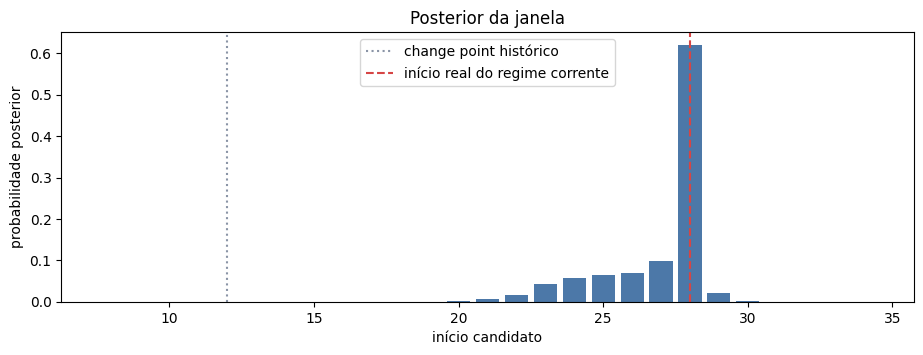

In [14]:
window_prob, model_prob = defaultdict(float), defaultdict(float)
for h in hypotheses:
    window_prob[h["start"]] += h["probability"]
    model_prob[h["model"]] += h["probability"]
print("probabilidade por modelo:")
for key,value in sorted(model_prob.items(),key=lambda q:q[1],reverse=True): print(f"  {key:12s}: {value:.8f}")
print()
print("cinco janelas mais prováveis:")
for key,value in sorted(window_prob.items(),key=lambda q:q[1],reverse=True)[:5]:
    label = "sem mudança" if key is None else f"{key} ({dates[key]})"
    print(f"  {label:20s}: {value:.8f}")
print()
print("Probabilidade atribuída a cada change point usado para gerar a série:")
for position, start in enumerate(change_points, 1):
    role = "histórico" if start != true_break else "início do regime corrente"
    print(f"  change point {position}: {start} ({dates[start]}), {role:25s}, P como início terminal={window_prob[start]:.8f}")
fig,ax=plt.subplots(figsize=(11,3.5))
ax.bar(starts,[window_prob[s] for s in starts],color="#4C78A8")
ax.axvline(change_points[0],color="#8A94A6",linestyle=":",label="change point histórico")
ax.axvline(change_points[1],color="#D64545",linestyle="--",label="início real do regime corrente")
ax.set(xlabel="início candidato",ylabel="probabilidade posterior",title="Posterior da janela")
ax.legend(); plt.show()


### Como interpretar os dois change points

O change point histórico e o change point terminal desempenham papéis diferentes. O gráfico mostra ambos, mas a distribuição `window_prob` responde somente: **qual data é o início mais plausível do regime que chega até o presente?** Por isso esperamos massa no segundo change point, não no primeiro.

Observe também que a massa pode se espalhar por meses próximos ao segundo change point. Parte dessa ambiguidade vem do ruído; outra parte vem da limitação estrutural do MVP: todo o passado anterior à janela é resumido por uma única reta, embora saibamos que ele próprio contenha dois regimes. Assim, este exemplo é mais realista e também mais difícil que o exemplo com uma única ruptura.

Se o objetivo operacional passar a ser recuperar **todos** os change points, a hipótese precisa conter uma sequência de segmentos e uma prior sobre a quantidade de rupturas. Isso é uma extensão do modelo; não deve ser confundido com simplesmente executar repetidamente o estimador terminal e tratar as respostas como independentes.


## 10. De onde vem o intervalo preditivo?

Num ponto futuro há duas variações: um novo erro residual, que gera o termo `1`, e incerteza dos coeficientes, cuja projeção é `x_future @ Vn @ x_future`. Condicionada a `sigma²`, a preditiva é normal. Integrar a variância desconhecida transforma-a em Student-t, com caudas mais largas.


In [15]:
best = max(hypotheses,key=lambda h:h["probability"])
future_age = n-best["start"]
future_basis = basis(best["model"],[future_age])
x_future = np.r_[np.zeros(2),future_basis[0]]
location = float(x_future@best["bn"])
parameter_part = float(x_future@best["Vn"]@x_future)
scale2_pred = best["dn"]/best["an"]*(1+parameter_part)
df = 2*best["an"]
q = student_t.ppf(0.975,df=df)
lower,upper = center+scale*(location-q*math.sqrt(scale2_pred)),center+scale*(location+q*math.sqrt(scale2_pred))
print("hipótese:",best["model"],"início",best["start"],dates[best["start"]])
print("idade futura:",future_age,"; linha x*:",x_future)
print(f"média x*@bn={location:.8f}")
print(f"incerteza dos coeficientes={parameter_part:.8f}; novo ruído=1.0")
print(f"graus de liberdade={df:.1f}")
print(f"forecast={center+scale*location:.4f}; intervalo 95%=[{lower:.4f}, {upper:.4f}]")


hipótese: linear início 28 2025-05
idade futura: 14 ; linha x*: [ 0.  0.  1. 14.]
média x*@bn=2.50698343
incerteza dos coeficientes=0.31127013; novo ruído=1.0
graus de liberdade=46.0
forecast=145.3847; intervalo 95%=[140.1916, 150.5778]


## 11. Conferência contra o pacote

A API integra todas as hipóteses, não apenas a melhor. Assim, seu forecast inclui dúvida sobre janela e modelo. Também separa variância **dentro** das hipóteses — ruído e coeficientes — e **entre** hipóteses — discordância de seleção. Além disso, ela repete a inferência em `g=n/2`, `g=n` e `g=2n`; isso torna visível se a conclusão depende demais da força da prior.


In [16]:
from probabilistic_window_forecast import BayesianConfig, BayesianForecastPipeline
config = BayesianConfig(min_before=8,min_after=8,forecast_horizon=6,candidate_models=models,prior_no_change=0.60,posterior_draws=4000,random_seed=1729)
pipeline = BayesianForecastPipeline(config)
result = pipeline.run(series,series_id="sintetica_tutorial")
print("ENTRADAS")
print("n=",len(series),"; change points geradores=",[(i,dates[i]) for i in change_points])
print("primeiras=",series[:3],"; últimas=",series[-3:])
print("modelos=",config.candidate_models,"; prior sem mudança=",config.prior_no_change)
print("centro robusto=",result.center,"; escala robusta=",result.scale)
print("estratégia da prior=",result.prior_strategy,"; g=",result.g_value)
print()
print("RESULTADO")
print("P(sem ruptura)=",result.probability_no_change,"; P(com ruptura)=",result.probability_change)
print("início recomendado=",result.recommended_window_start_t,"; modelo=",result.recommended_model)
print("probabilidades dos modelos=",result.model_probabilities)
print("incerteza total=",result.predictive_uncertainty_index,"; incerteza de seleção=",result.selection_uncertainty_index)
print("sensível a g?",result.prior_sensitive,"; maior amplitude normalizada do forecast=",result.max_g_sensitivity_forecast_spread)
print("condição da matriz selecionada=",result.selected_design_condition_number)
print("revisão humana?",result.human_intervention_required)
print()
print("SENSIBILIDADE: multiplicador | g | janela | modelo | P(sem mudança)")
for item in result.g_sensitivity_results:
    print(f"{item.g_multiplier:11.1f} | {item.g_value:4.1f} | {str(item.recommended_window_start_t):7s} | {item.recommended_model:11s} | {item.probability_no_change:.8f}")
print()
print("mês    | média   | inferior | superior | var. dentro | var. entre")
for p in result.forecast:
    print(f"{p.t} | {p.mean:7.3f} | {p.lower:8.3f} | {p.upper:8.3f} | {p.within_hypothesis_variance:11.5f} | {p.between_hypothesis_variance:10.5f}")


ENTRADAS
n= 42 ; change points geradores= [(12, '2024-01'), (28, '2025-05')]
primeiras= [(100.3, '2023-01'), (99.8, '2023-02'), (100.60000000000001, '2023-03')] ; últimas= [(140.70000000000002, '2026-04'), (143.1, '2026-05'), (144.20000000000002, '2026-06')]
modelos= ('constant', 'linear', 'logarithmic') ; prior sem mudança= 0.6
centro robusto= 110.72500000000001 ; escala robusta= 13.825245000000013
estratégia da prior= zellner_g_prior_unit_information ; g= 42.0

RESULTADO
P(sem ruptura)= 3.225794995449684e-11 ; P(com ruptura)= 0.999999999967742
início recomendado= 2025-05 ; modelo= linear
probabilidades dos modelos= {'constant': 2.294376969833806e-09, 'linear': 0.9970330752011985, 'logarithmic': 0.0029669225044245315}
incerteza total= 0.0454910139047654 ; incerteza de seleção= 0.00303297086140612
sensível a g? False ; maior amplitude normalizada do forecast= 0.0830682171734757
condição da matriz selecionada= 42.53794726563778
revisão humana? False

SENSIBILIDADE: multiplicador | g | j

probabilidades: cálculo manual versus pacote
constant     manual=0.0000000023 pacote=0.0000000023 diferença=1.83e-21
linear       manual=0.9970330752 pacote=0.9970330752 diferença=1.33e-15
logarithmic  manual=0.0029669225 pacote=0.0029669225 diferença=9.49e-16


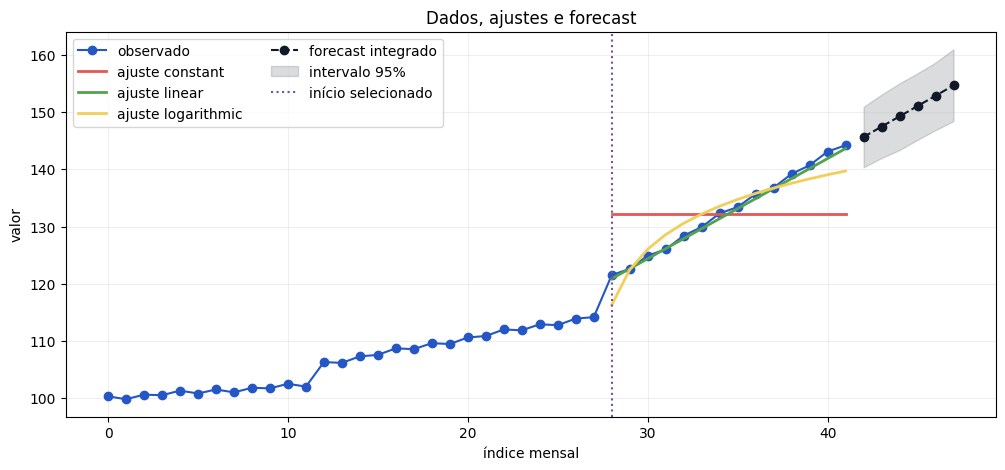

In [17]:
print("probabilidades: cálculo manual versus pacote")
for model in models:
    print(f"{model:12s} manual={model_prob[model]:.10f} pacote={result.model_probabilities[model]:.10f} diferença={abs(model_prob[model]-result.model_probabilities[model]):.2e}")

future_x=np.arange(n,n+len(result.forecast))
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(range(n),y,"o-",color="#2457C5",label="observado")
colors={"constant":"#E45756","linear":"#54A24B","logarithmic":"#F2CF5B"}
for model,view in result.model_views.items():
    start_idx=0 if view.no_change else dates.index(view.window_start_t)
    ax.plot(range(start_idx,n),[p.value for p in view.fitted],linewidth=2,color=colors[model],label=f"ajuste {model}")
means=np.array([p.mean for p in result.forecast]); lows=np.array([p.lower for p in result.forecast]); highs=np.array([p.upper for p in result.forecast])
ax.plot(future_x,means,"o--",color="#111827",label="forecast integrado")
ax.fill_between(future_x,lows,highs,color="#111827",alpha=.15,label="intervalo 95%")
ax.axvline(dates.index(result.selected_window_start_t),color="#7A5195",linestyle=":",label="início selecionado")
ax.set(xlabel="índice mensal",ylabel="valor",title="Dados, ajustes e forecast")
ax.legend(ncol=2); ax.grid(alpha=.2); plt.show()


## 12. Escolha humana sem apagar a recomendação

`model_views` permite alternar visualmente entre modelos na janela selecionada. Um novo `run` pode receber `window_start` e `model_override`. A recomendação automática permanece em `recommended_*`; a decisão usada fica em `selected_*`.


In [18]:
for model,view in result.model_views.items():
    print(f"{model:12s}: P(modelo|janela)={view.conditional_probability:.8f}; ajuste={len(view.fitted)} pontos; forecast={len(view.forecast)}")
reviewed=pipeline.run(series,window_start=dates[true_break-1],model_override="linear")
print()
print("automático:",reviewed.recommended_window_start_t,reviewed.recommended_model)
print("manual usado:",reviewed.selected_window_start_t,reviewed.selected_model)
print("fontes:",reviewed.window_selection_source,reviewed.model_selection_source)


constant    : P(modelo|janela)=0.00000000; ajuste=14 pontos; forecast=6
linear      : P(modelo|janela)=0.99926005; ajuste=14 pontos; forecast=6
logarithmic : P(modelo|janela)=0.00073995; ajuste=14 pontos; forecast=6



automático: 2025-05 linear
manual usado: 2025-04 linear
fontes: manual manual


## 13. Exercício

Antes de executar: preveja o que ocorre ao mover `EXERCISE_BREAK` de 14 para 20; elevar `NOISE_MULTIPLIER` de 1 para 4; e reduzir `POST_SLOPE` de 1.4 para 0.4. A massa da janela deve mover-se, espalhar-se e, no terceiro caso, dar mais espaço à hipótese sem ruptura.


In [19]:
EXERCISE_BREAK=14
NOISE_MULTIPLIER=1.0
POST_SLOPE=1.4
exercise_values=[]
for i in range(n):
    clean=80+.3*i if i<EXERCISE_BREAK else 90+POST_SLOPE*(i-EXERCISE_BREAK)
    exercise_values.append(clean+NOISE_MULTIPLIER*noise_pattern[i%len(noise_pattern)])
exercise_result=pipeline.run(list(zip(exercise_values,dates)),series_id="exercicio")
print("ruptura geradora:",EXERCISE_BREAK,dates[EXERCISE_BREAK])
print("início recomendado:",exercise_result.recommended_window_start_t)
print("P(com ruptura):",exercise_result.probability_change)
print("modelo:",exercise_result.recommended_model)
print("conjunto crível:",exercise_result.window_credible_set)


ruptura geradora: 14 2024-03
início recomendado: 2024-03
P(com ruptura): 0.999828877418035
modelo: linear
conjunto crível: ('2024-03', '2024-02', '2024-04', '2024-01', '2023-11', '2023-12')


### Resposta esperada e armadilhas

- Ao mover a ruptura, a massa acompanha a data se há observações suficientes dos dois lados.
- Ao aumentar o ruído, datas vizinhas ganham massa e o conjunto crível cresce.
- Ao enfraquecer a mudança, os parâmetros adicionais deixam de ser compensados e `P(com ruptura)` tende a cair.

**Erro comum:** comparar apenas erros de janelas com comprimentos diferentes. Janelas curtas enfrentam menos dados. Aqui todas explicam o mesmo lookback e a evidência integra os parâmetros.

As probabilidades continuam condicionais às famílias, ao erro normal e às priors. A g-prior remove a necessidade de inventar uma diagonal ou agrupar séries, mas não elimina a escolha de `g`; por isso a sensibilidade já faz parte do resultado. O exponencial permanece experimental e, na versão atual, exige `center_series=False`. Quando novos valores reais surgirem, valide prospectivamente a cobertura dos intervalos.
